# MELBOURNE SOLAR ENERGY REPORT FOR YEARS 2011-2025

#### Prepared by: Maribel Quiambao | DATA ANALYST | Australian Renewable Energy Agency (ARENA)

23rd of November 2025

## Executive Summary

Australia generally has a sunny weather with an average of 3,500 to 3,600 hours of sunshine per year, among the highest globally. Thereby solar energy, being abundant in Australia, it's cost-effectiveness and it being a clean renewable energy has a potential of being used on a large scale energy generation. This report focus specifically to the Melbourne solar market aiming to inform and refine local policy development to meet the city’s unique needs. 

## Objective

The objective of this report is to analyze the relationship between solar installations and housing characteristics accross melbourne suburbs. By integrating the Solar installation and capacity data with the Melbourne housing data we aim to identify the key demographic or geographic factors that most or least influence solar adoption within the Melbourne area.

The findings will provide evidence-based insights to guide policymakers in designing tailor made solar policies that will address barriers in low-adoption areas and help Melbourne transition to become the number 1 in sustainable, environment friendly, large scale solar energy generation in the country.


# Datasets used

In [1]:
installs_url = "https://cer.gov.au/document/sgu-solar-installations-2011-to-present-and-totals"
capacity_url = "https://cer.gov.au/document/sgu-solar-capacity-2011-to-present-and-totals"
postcode_url = "https://github.com/Elkfox/Australian-Postcode-Data/blob/master/au_postcodes.csv"
melbournehousing_url = "https://www.kaggle.com/datasets/saadmehar/melbourne-housing-fullcsv"

# Methodology

All 4 datasets will be uploaded, prepared and evaluated. The data is cleaned by renaming column names, dropping unnecessary data, changing datatypes. This will prepare the data to be easily merged with each other.

In [2]:
import pandas as pd

In [3]:
#upload installs_url dataset
df = pd.read_csv(R'C:\Users\marib\Downloads\starter_pack\data\sgu-solar-installations-2011-to-present-and-totals.csv')
df_install = df

In [4]:
#upload capacity_url dataset
df = pd.read_csv(R'C:\Users\marib\Downloads\starter_pack\data\sgu-solar-capacity-2011-to-present-and-totals.csv')
df_capacity = df

In [5]:
#upload postcode_url dataset
df = pd.read_csv(R'C:\Users\marib\Downloads\aus_postcode.csv')
df_aupostcode = df

In [6]:
#upload melbourne_url dataset
df = pd.read_csv(R"C:\Users\marib\Downloads\data\data\Melbourne_housing_FULL.csv")
df_melbhousing = df

In [7]:
#display maximum of 10 rows per dataset. First 5 row and last 5 rows.
pd.set_option('display.max_rows', 10)

#### Solar Installations Dataset

In [8]:
df_install


,Small Unit Installation Postcode,Historic Total Installation Quantity (2001 - 2010),Jan 2011 - Installation Quantity,Feb 2011 - Installation Quantity,Mar 2011 - Installation Quantity,Apr 2011 - Installation Quantity,May 2011 - Installation Quantity,Jun 2011 - Installation Quantity,Jul 2011 - Installation Quantity,Aug 2011 - Installation Quantity,...,Nov 2024 - Installation Quantity,Dec 2024 - Installation Quantity,Jan 2025 - Installation Quantity,Feb 2025 - Installation Quantity,Mar 2025 - Installation Quantity,Apr 2025 - Installation Quantity,May 2025 - Installation Quantity,Jun 2025 - Installation Quantity,Jul 2025 - Installation Quantity,Total Installation Quantity
0,0,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
1,200,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,800,7,0,0,0,0,1,0,1,0,...,2,0,0,0,3,1,0,2,0,147
3,801,2,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,12
4,803,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2805,7469,2,0,0,1,0,1,0,0,0,...,0,0,0,1,1,3,0,0,1,78
2806,7470,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,3,1,0,0,74
2807,7802,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2808,8576,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


In [9]:
# Rename column
df_install = df_install.rename(columns={'Small Unit Installation Postcode': 'postcode'})

# Drop column/s
df_install = df_install.drop(columns=['Historic Total Installation Quantity (2001 - 2010)','Total Installation Quantity'])

# Change Postcode datatype from integer to string and format postcode to make it 4 digit
df_install.postcode = df_install.postcode.astype('string').str.zfill(4)
df_install.dtypes

# Unpivot data
df_install = df_install.melt(id_vars='postcode', var_name='date', value_name='quantity')

# Format date and drop installation quantity
df_install.date = pd.to_datetime(df_install.date, format='%b %Y - Installation Quantity')

df_install

,postcode,date,quantity
0,0000,2011-01-01,0
1,0200,2011-01-01,0
2,0800,2011-01-01,0
3,0801,2011-01-01,0
4,0803,2011-01-01,0
...,...,...,...
491745,7469,2025-07-01,1
491746,7470,2025-07-01,0
491747,7802,2025-07-01,0
491748,8576,2025-07-01,0


#### Solar Capacity Dataset

In [10]:
# Rename a column
df_capacity = df_capacity.rename(columns={'Small Unit Postcode': 'postcode'})
df_capacity

# Drop column/s
df_capacity = df_capacity.drop(columns=['Historic Total Rated Power Output In kW (2001 - 2010)','Total Rated Power Output In kW'])

# Change postcode data type from integer to string and make it to 4 digit
df_capacity.postcode = df_capacity.postcode.astype('string').str.zfill(4)
df_capacity.dtypes

# Unpivot data
df_capacity = df_capacity.melt(id_vars="postcode", var_name='date', value_name='kW')

# Format data
df_capacity.date = pd.to_datetime(df_capacity.date, format='%b %Y - Rated Power Output In kW')

df_capacity

,postcode,date,kW
0,0000,2011-01-01,0.00
1,0200,2011-01-01,0.00
2,0800,2011-01-01,0.00
3,0801,2011-01-01,0.00
4,0803,2011-01-01,0.00
...,...,...,...
491745,7469,2025-07-01,1.76
491746,7470,2025-07-01,0.00
491747,7802,2025-07-01,0.00
491748,8576,2025-07-01,0.00


#### Postcode Dataset

In [11]:
# Drop column/s
df_aupostcode = df_aupostcode.drop(columns=['state_code'])
df_aupostcode

# Change Postcode Datatype and format to make it 4 digit
df_aupostcode.postcode = df_aupostcode.postcode.astype('string').str.zfill(4)

#### Melbourne Housing Dataset

Melbourne housing dataset will be uploaded and cleaned. There are 2 filtered dataset created in this step. 1 is the df_melb_medianprice where the median prices per suburb is calculated and the 2 is the the df_melb_propertycount where the property count per suburb will show. Both datasets will be used in the merging of all datasets to create 1 table.

In [12]:
df_melbhousing

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.80140,144.99580,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.79960,144.99840,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.80790,144.99340,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.81140,145.01160,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.80930,144.99440,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34852,Yarraville,13 Burns St,4,h,1480000.0,PI,Jas,24/02/2018,6.3,3013.0,...,1.0,3.0,593.0,NaN,NaN,Maribyrnong City Council,-37.81053,144.88467,Western Metropolitan,6543.0
34853,Yarraville,29A Murray St,2,h,888000.0,SP,Sweeney,24/02/2018,6.3,3013.0,...,2.0,1.0,98.0,104.0,2018.0,Maribyrnong City Council,-37.81551,144.88826,Western Metropolitan,6543.0
34854,Yarraville,147A Severn St,2,t,705000.0,S,Jas,24/02/2018,6.3,3013.0,...,1.0,2.0,220.0,120.0,2000.0,Maribyrnong City Council,-37.82286,144.87856,Western Metropolitan,6543.0
34855,Yarraville,12/37 Stephen St,3,h,1140000.0,SP,hockingstuart,24/02/2018,6.3,3013.0,...,NaN,NaN,NaN,NaN,NaN,Maribyrnong City Council,NaN,NaN,Western Metropolitan,6543.0


In [13]:
# Drop null item
df_melbhousing = df.dropna()

# Drop column/s
df_melbhousing = df_melbhousing.drop(columns=['Address','Suburb','Type','Rooms','Method','CouncilArea','SellerG','Distance','Bathroom','Bedroom2','Car','Landsize','BuildingArea','YearBuilt','Regionname'])

# Rename column name
df_melbhousing = df_melbhousing.rename(columns={'Date': 'date'})
df_melbhousing = df_melbhousing.rename(columns={'Postcode': 'postcode'})
df_melbhousing = df_melbhousing.rename(columns={'Lattitude': 'lattitude'})
df_melbhousing = df_melbhousing.rename(columns={'Longtitude': 'longtitude'})
df_melbhousing = df_melbhousing.rename(columns={'Propertycount': 'property_count'})
df_melbhousing = df_melbhousing.rename(columns={'Price': 'price'})

# Change Postcode Datatype and format to make it 4 digit
df_melbhousing['postcode'] = df_melbhousing['postcode'].fillna(0).astype('int')
df_melbhousing['property_count'] = df_melbhousing['property_count'].fillna(0).astype(int)
df_melbhousing.postcode = df_melbhousing.postcode.astype('string').str.zfill(4)

# Change date format
df_melbhousing['date'] = pd.to_datetime(df_melbhousing['date'], dayfirst=True).dt.strftime('%Y-%m')
df_melbhousing

,price,date,postcode,lattitude,longtitude,property_count
2,1035000.0,2016-02,3067,-37.80790,144.99340,4019
4,1465000.0,2017-03,3067,-37.80930,144.99440,4019
6,1600000.0,2016-06,3067,-37.80720,144.99410,4019
11,1876000.0,2016-05,3067,-37.80240,144.99930,4019
14,1636000.0,2016-10,3067,-37.80600,144.99540,4019
...,...,...,...,...,...,...
34847,500000.0,2018-02,3750,-37.61940,145.03951,2940
34849,570000.0,2018-02,3750,-37.61031,145.03393,2940
34853,888000.0,2018-02,3013,-37.81551,144.88826,6543
34854,705000.0,2018-02,3013,-37.82286,144.87856,6543


In [14]:
df = df_melbhousing.groupby(['postcode'])['price'].median()
df_melb_medianprice = df
df_melb_medianprice

postcode
3000     535000.0
3002    1300000.0
3003     800000.0
3006     600000.0
3011     840500.0
          ...    
3809     563000.0
3810     493000.0
3910     600000.0
3976     512500.0
3977     642500.0
Name: price, Length: 194, dtype: float64

In [15]:
# Drop column/s
df_melbhousing = df_melbhousing.drop(columns=['price', 'date', 'lattitude', 'longtitude'])

#Drop duplicates
df = df_melbhousing.drop_duplicates(subset=['postcode'])
df_melb_propertycount = df
df_melb_propertycount

,postcode,property_count
2,3067,4019
66,3042,3464
133,3206,3280
195,3078,2211
230,3018,5301
...,...,...
22685,3335,1490
23573,3340,2871
29969,3096,642
30663,3809,2768


# Merge and format data

We are now merging the cleaned/filtered data from all 4 datasets to be able to create 1 consolidated dataset for the analysis. We are also formating some data as we go to make the merging possible.

#### Merge solar and capacity datasets

In [16]:
df = pd.merge(df_install, df_capacity, how='inner', on=['postcode','date'])
df_solar = df
df_solar

,postcode,date,quantity,kW
0,0000,2011-01-01,0,0.00
1,0200,2011-01-01,0,0.00
2,0800,2011-01-01,0,0.00
3,0801,2011-01-01,0,0.00
4,0803,2011-01-01,0,0.00
...,...,...,...,...
491745,7469,2025-07-01,1,1.76
491746,7470,2025-07-01,0,0.00
491747,7802,2025-07-01,0,0.00
491748,8576,2025-07-01,0,0.00


#### Merge df_solar (solar& capacity dataset) with the Postcode Dataset.


In [17]:
# Merge df_solar & Postcode Datasets
df = pd.merge(df_solar, df_aupostcode, how='inner', on=['postcode'])
df_solarreport = df
df_solarreport

# Change date format
df_solarreport['date'] = pd.to_datetime(df_solarreport['date']).dt.strftime('%Y-%m')
df_solarreport



,postcode,date,quantity,kW,suburb,state
0,0800,2011-01,0,0.00,Darwin City,Northern Territory
1,0810,2011-01,2,3.02,Jingili,Northern Territory
2,0812,2011-01,1,3.00,Leanyer,Northern Territory
3,0820,2011-01,0,0.00,Stuart Park,Northern Territory
4,0822,2011-01,0,0.00,Rakula,Northern Territory
...,...,...,...,...,...,...
460945,7466,2025-07,0,0.00,Gormanston,Tasmania
460946,7467,2025-07,1,13.16,Queenstown (Tas.),Tasmania
460947,7468,2025-07,0,0.00,Strahan,Tasmania
460948,7469,2025-07,1,1.76,Granville Harbour,Tasmania


#### Merge df_solarreport(solar, capacity & postcode dataset) with the melbourne housing dataset


In [18]:
# Merge df_solarreport and df_melbsuburb
df = pd.merge(df_solarreport, df_melbhousing, how='inner', on=['postcode'])
df_solarmelb = df
df_solarmelb


,postcode,date,quantity,kW,suburb,state,property_count
0,3000,2011-01,0,0.000,Melbourne,Victoria,17496
1,3000,2011-01,0,0.000,Melbourne,Victoria,17496
2,3000,2011-01,0,0.000,Melbourne,Victoria,17496
3,3000,2011-01,0,0.000,Melbourne,Victoria,17496
4,3000,2011-01,0,0.000,Melbourne,Victoria,17496
...,...,...,...,...,...,...,...
1555220,3977,2025-07,36,274.655,Cranbourne East,Victoria,7680
1555221,3977,2025-07,36,274.655,Cranbourne East,Victoria,7680
1555222,3977,2025-07,36,274.655,Cranbourne East,Victoria,1240
1555223,3977,2025-07,36,274.655,Cranbourne East,Victoria,2756


In [19]:
# Move suburb column
col = df.pop('suburb')
df_solarmelb.insert(1, 'suburb', col)

#drop duplicates
df_solarmelb = df.drop_duplicates(subset=['postcode'])

# Drop Columns
df_solarmelb = df_solarmelb.drop(columns=['suburb','state','date'])

#Rename price to median_price
df_solarmelb = df_solarmelb.rename(columns={'price': 'median_price'})

df_solarmelb

,postcode,quantity,kW,property_count
0,3000,0,0.000,17496
31,3002,0,0.000,3040
38,3003,0,0.000,2230
59,3006,0,0.000,8400
81,3011,4,5.984,7570
...,...,...,...,...
8865,3809,1,2.220,2768
8866,3810,28,53.520,17384
8873,3910,14,32.634,8743
8877,3976,20,34.360,8256


In [20]:
# Merge df_melbsuburb with df_melb_medianprice
df = pd.merge(df_solarmelb, df_melb_medianprice, how='inner', on=['postcode'])
df_solarmelbourne = df

#rename column price to median_price
df_solarmelbourne = df_solarmelbourne.rename(columns={'price': 'median_price'})
df_solarmelbourne = df_solarmelbourne.rename(columns={'quantity': 'installation_quantity'})
df_solarmelbourne = df_solarmelbourne.rename(columns={'kW': 'kW_capacity'})

df_solarmelbourne

,postcode,installation_quantity,kW_capacity,property_count,median_price
0,3000,0,0.000,17496,535000.0
1,3002,0,0.000,3040,1300000.0
2,3003,0,0.000,2230,800000.0
3,3006,0,0.000,8400,600000.0
4,3011,4,5.984,7570,840500.0
...,...,...,...,...,...
189,3809,1,2.220,2768,563000.0
190,3810,28,53.520,17384,493000.0
191,3910,14,32.634,8743,600000.0
192,3976,20,34.360,8256,512500.0


In [21]:
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.precision', 3,
                       ):
    print(df_solarmelbourne)

    postcode  installation_quantity  kW_capacity  property_count  median_price
0       3000                      0        0.000           17496     5.350e+05
1       3002                      0        0.000            3040     1.300e+06
2       3003                      0        0.000            2230     8.000e+05
3       3006                      0        0.000            8400     6.000e+05
4       3011                      4        5.984            7570     8.405e+05
5       3012                     12       22.585            3873     8.050e+05
6       3013                     10       17.625            6543     9.825e+05
7       3015                      5        6.850            5498     9.400e+05
8       3016                      5        7.200            6380     1.292e+06
9       3018                      4        7.160            5301     7.660e+05
10      3019                      4        9.540            3589     6.450e+05
11      3020                     20       35.610    

In [22]:
# Check for missing values
print(df_solarmelbourne.isnull())

# Check data types of each column
df_solarmelbourne.dtypes

     postcode  installation_quantity  kW_capacity  property_count  \
0       False                  False        False           False   
1       False                  False        False           False   
2       False                  False        False           False   
3       False                  False        False           False   
4       False                  False        False           False   
..        ...                    ...          ...             ...   
189     False                  False        False           False   
190     False                  False        False           False   
191     False                  False        False           False   
192     False                  False        False           False   
193     False                  False        False           False   

     median_price  
0           False  
1           False  
2           False  
3           False  
4           False  
..            ...  
189         False  
190        

postcode                 string[python]
installation_quantity             int64
kW_capacity                     float64
property_count                    int64
median_price                    float64
dtype: object

# Visualization

In [23]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [24]:
df_solarmelbourne.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   postcode               194 non-null    string 
 1   installation_quantity  194 non-null    int64  
 2   kW_capacity            194 non-null    float64
 3   property_count         194 non-null    int64  
 4   median_price           194 non-null    float64
dtypes: float64(2), int64(2), string(1)
memory usage: 7.7 KB


In [25]:
%%capture output

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Create a copy of the dataframe
df_solarmelbourne = df_solarmelbourne.copy()

df_solarmelbourne.iloc[:,1:] = scaler.fit_transform(df_solarmelbourne.iloc[:,1:])

# Select only numeric columns for scaling
numeric_columns = df_solarmelbourne.select_dtypes(include=['float64', 'int64']).columns

# Apply StandardScaler only to numeric columns
df_solarmelbourne[numeric_columns] = scaler.fit_transform(df_solarmelbourne[numeric_columns])

df_solarmelbourne

In [26]:
%%capture output

from sklearn.cluster import KMeans

k_values = range(1, 10)
inertia = []
features = df_solarmelbourne[['installation_quantity', 'kW_capacity', 'median_price', 'property_count']]
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

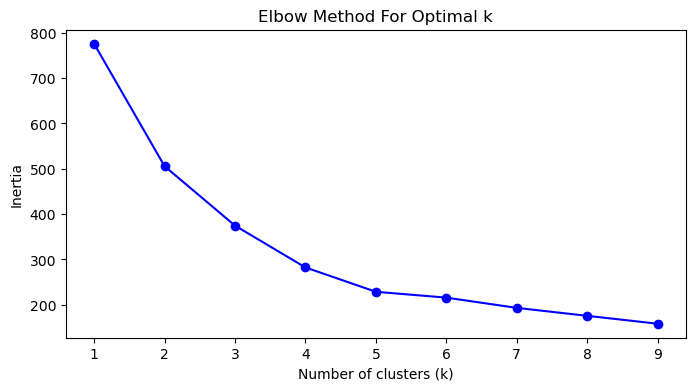

In [27]:
# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(k_values, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.xticks(k_values)
plt.show()

In [28]:
%%capture output

from sklearn.metrics import silhouette_score

k_values = range(4, 9)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(features)
    silhouette_avg = silhouette_score(features, cluster_labels)
    silhouette_scores.append(silhouette_avg)



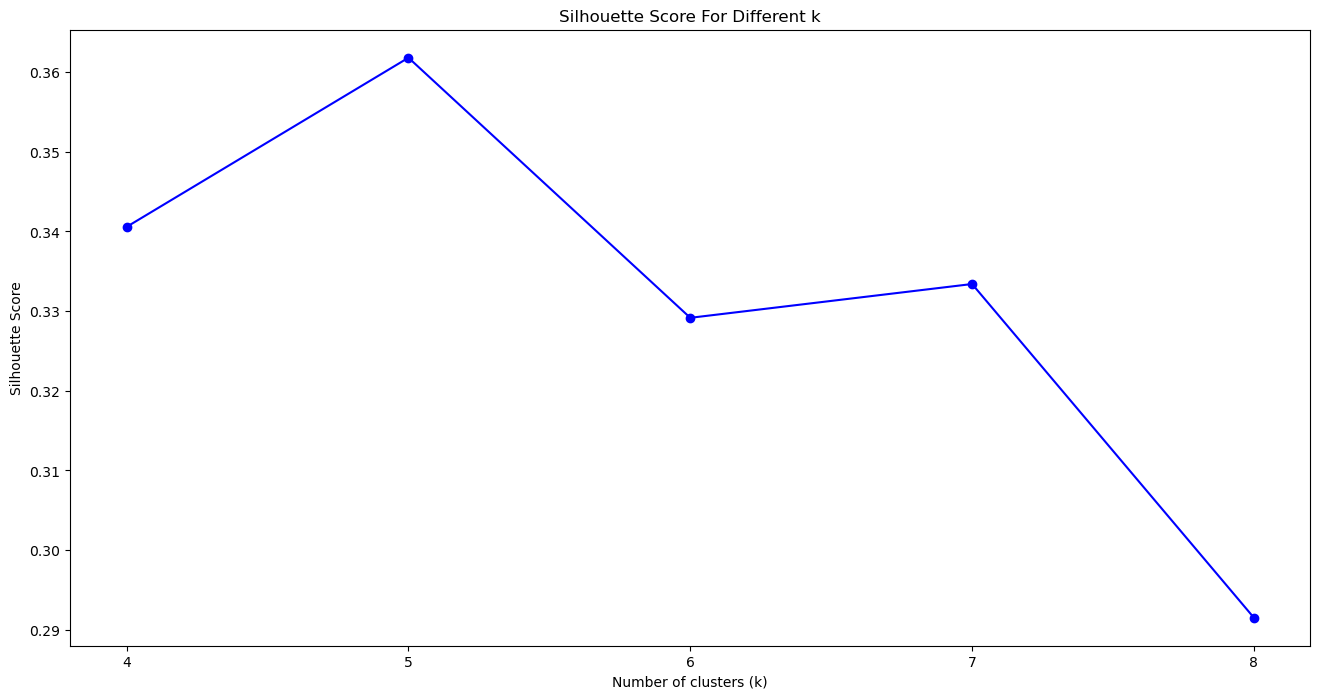

In [29]:
# Plot the Silhouette Scores
plt.figure(figsize=(16, 8))
plt.plot(k_values, silhouette_scores, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score For Different k')
plt.xticks(k_values)
plt.show()

In [30]:
# Add your code to perform KMeans clustering using the optimal number of clusters you selected
import matplotlib.pyplot as plt
import sklearn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


kmeans = KMeans(n_clusters=5)
kmeans.fit(features)

# This last part has been created for you - ensure you do not change this part to maintain continuity with other sections.
df_solarmelbourne['y_pred'] = kmeans.labels_

df_solarmelbourne.head(10)

C:\Users\marib\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,postcode,installation_quantity,kW_capacity,property_count,median_price,y_pred
0,3000,-0.836900,-0.842322,2.956612,-1.072435,0
1,3002,-0.836900,-0.842322,-0.745500,0.874801,2
2,3003,-0.836900,-0.842322,-0.952937,-0.397903,4
3,3006,-0.836900,-0.842322,0.627170,-0.906984,4
4,3011,-0.496168,-0.574767,0.414611,-0.294814,4
5,3012,0.185295,0.167493,-0.532172,-0.385175,4
6,3013,0.014929,-0.054277,0.151602,0.066634,4
7,3015,-0.410985,-0.536047,-0.116018,-0.041546,4
8,3016,-0.410985,-0.520397,0.109858,0.855710,2
9,3018,-0.496168,-0.522186,-0.166468,-0.484446,4


In [31]:
df_solarmelbourne.tail (10)

,postcode,installation_quantity,kW_capacity,property_count,median_price,y_pred
184,3803,-0.581351,-0.503407,-0.569306,-0.848440,4
185,3805,3.337061,3.129603,0.877119,-0.834440,1
186,3806,3.422244,3.607303,2.853406,-0.563354,1
187,3807,-0.751717,-0.757370,-0.926815,-0.728805,4
188,3808,-0.836900,-0.842322,-1.274848,-0.716078,4
189,3809,-0.751717,-0.743062,-0.815157,-1.001164,4
190,3810,1.548221,1.550651,2.927929,-1.179342,0
191,3910,0.355660,0.616802,0.715011,-0.906984,0
192,3976,0.866758,0.693974,0.590293,-1.129707,3
193,3977,4.359256,4.707928,-0.818231,-0.798804,1


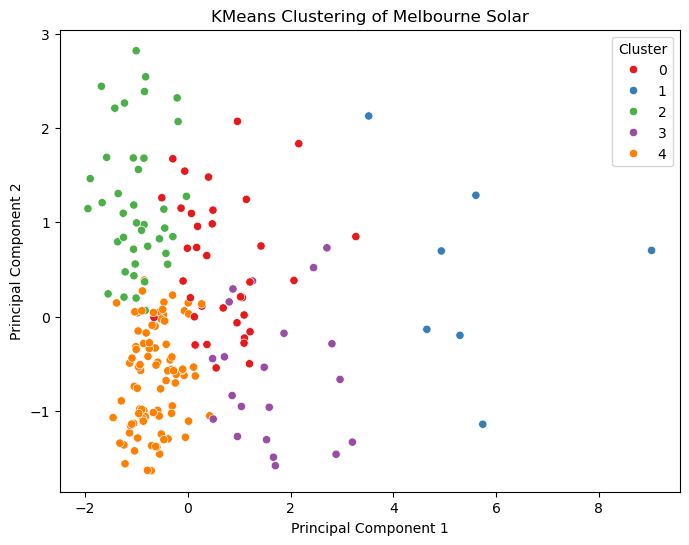

In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principal_components = pca.fit_transform(features)
df_solarmelbourne['pc1'] = principal_components[:, 0]
df_solarmelbourne['pc2'] = principal_components[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(x='pc1', y='pc2', hue='y_pred', palette='Set1', data=df_solarmelbourne)
plt.title('KMeans Clustering of Melbourne Solar')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

## Initial Observation
The clusters are well separated into 4 distinct clusters, as seen on the Elbow Method and the Silhouette Method. It suggests strong underlying patterns in the data. As for the KMeans Clustering method, it shows that Cluster 0 and cluster 2 are more dispersed indicating variability in their characteristics like in their median price or number of installations. While cluster 1 and 3 are more compact indicating consistency in their characteristics.

# SIGNIFICANCE TESTING

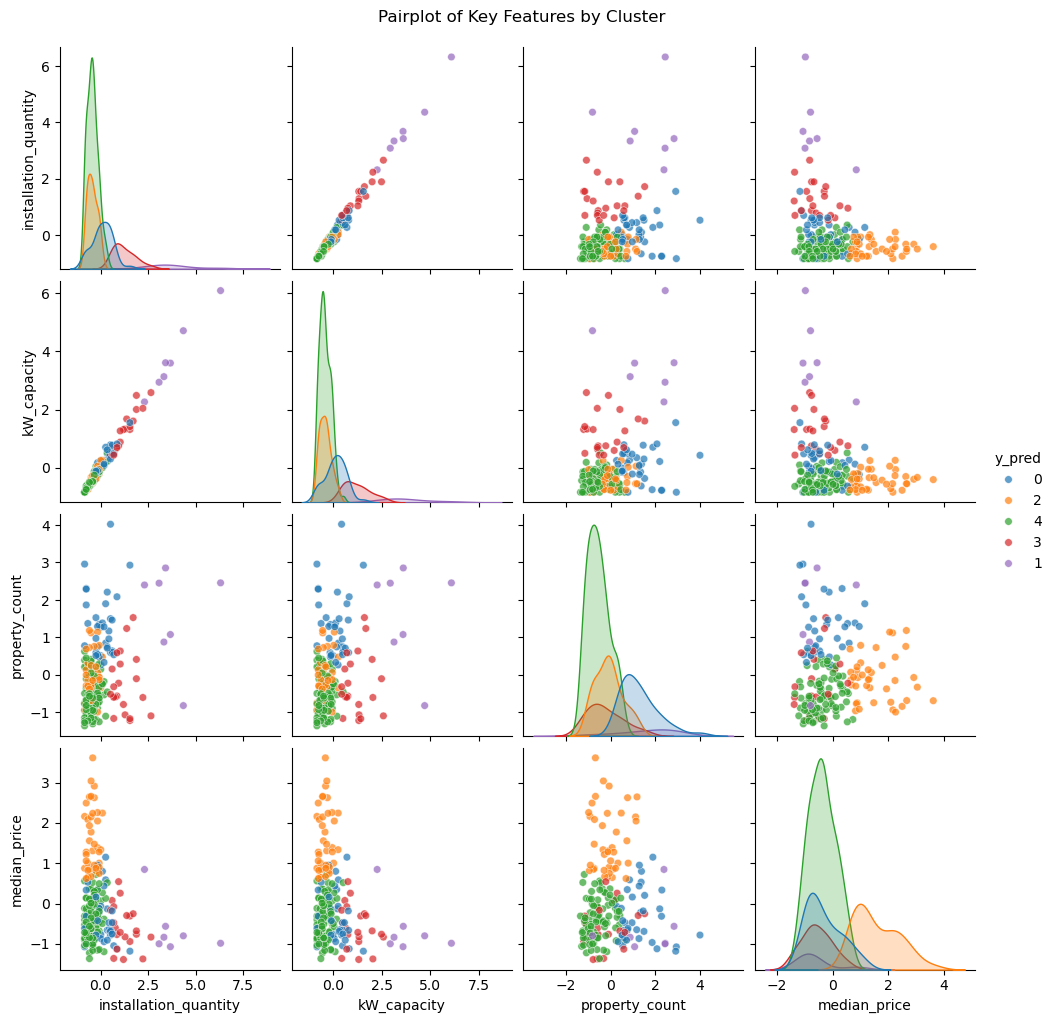

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical features + cluster  label
pairplot_features = [
    "installation_quantity",
    "kW_capacity",
    "property_count",
    "median_price",
    "y_pred"
]

# Create a new DataFrame for pairplot
df_pairplot = df_solarmelbourne[pairplot_features].copy()
df_pairplot["y_pred"] = df_pairplot["y_pred"].astype(str)  # convert to string for colouring

# Generate pairplot
sns.pairplot(
    df_pairplot,
    hue="y_pred",     # color points by cluster
    diag_kind="kde",   # kernel density curves on diagonals
    plot_kws={"alpha": 0.7, "s": 30} # adjust appearance
)

plt.suptitle("Pairplot of Key Features by Cluster", y=1.02)
plt.show()


In [47]:
# For K-means clustering
from sklearn.cluster import KMeans
import numpy as np

# Set the random seed for reproducibility
np.random.seed(42)  # You can use any integer value

# Create a K-means model with a fixed random_state
kmeans = KMeans(n_clusters=3, random_state=42)  

# Setting random_state ensures consistent results
kmeans.fit(df_solarmelbourne)



C:\Users\marib\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3, random_state=42)

## Null hypothesis
Ho : There is no significant difference between Cluster 1 and Cluster 3.



## Perform T-test

In [41]:
from scipy.stats import ttest_ind

# Split into 5 clusters
cluster0 = df_solarmelbourne[df_solarmelbourne['y_pred'] == 0]
cluster1 = df_solarmelbourne[df_solarmelbourne['y_pred'] == 1]
cluster2 = df_solarmelbourne[df_solarmelbourne['y_pred'] == 2]
cluster3 = df_solarmelbourne[df_solarmelbourne['y_pred'] == 3]
cluster4 = df_solarmelbourne[df_solarmelbourne['y_pred'] == 4]

#Count number of suburb per cluster
cluster0_count = cluster0.count()
print ("Number of suburb in cluster 0 : ", cluster0_count)
cluster1_count = cluster1.count()
print ("Number of suburb in cluster 1 : ", cluster1_count)
cluster2_count = cluster2.count()
print ("Number of suburb in cluster 2 : ", cluster2_count)
cluster3_count = cluster3.count()
print ("Number of suburb in cluster 3 : ", cluster3_count)
cluster4_count = cluster4.count()
print ("Number of suburb in cluster 4 : ", cluster4_count)


Number of suburb in cluster 0 :  postcode                 37
installation_quantity    37
kW_capacity              37
property_count           37
median_price             37
y_pred                   37
pc1                      37
pc2                      37
dtype: int64
Number of suburb in cluster 1 :  postcode                 7
installation_quantity    7
kW_capacity              7
property_count           7
median_price             7
y_pred                   7
pc1                      7
pc2                      7
dtype: int64
Number of suburb in cluster 2 :  postcode                 40
installation_quantity    40
kW_capacity              40
property_count           40
median_price             40
y_pred                   40
pc1                      40
pc2                      40
dtype: int64
Number of suburb in cluster 3 :  postcode                 21
installation_quantity    21
kW_capacity              21
property_count           21
median_price             21
y_pred                   

In [42]:
numeric_cols = cluster0.select_dtypes(include=['number']).columns

cluster0_mean = cluster0[numeric_cols].mean()
print ("Cluster 0 mean value : ", cluster0_mean)
cluster1_mean = cluster1[numeric_cols].mean()
print ("Cluster 1 mean value: ", cluster1_mean)
cluster2_mean = cluster2[numeric_cols].mean()
print ("Cluster 2 mean value: ", cluster2_mean)
cluster3_mean = cluster3[numeric_cols].mean()
print ("Cluster 3 mean value: ", cluster3_mean)
cluster4_mean = cluster3[numeric_cols].mean()
print ("Cluster 4 mean value: ", cluster4_mean)


Cluster 0 mean value :  installation_quantity    0.090903
kW_capacity              0.107504
property_count           1.286069
median_price            -0.329613
y_pred                   0.000000
pc1                      0.643148
pc2                      0.523395
dtype: float64
Cluster 1 mean value:  installation_quantity    3.787314
kW_capacity              3.760626
property_count           1.613429
median_price            -0.628444
y_pred                   1.000000
pc1                      5.540659
pc2                      0.476072
dtype: float64
Cluster 2 mean value:  installation_quantity   -0.440799
kW_capacity             -0.426308
property_count          -0.088423
median_price             1.575729
y_pred                   2.000000
pc1                     -0.989199
pc2                      1.195670
dtype: float64
Cluster 3 mean value:  installation_quantity    1.243996
kW_capacity              1.208943
property_count          -0.244602
median_price            -0.573990
y_pred      

In [45]:
# Define features to compare
features = [ 'installation_quantity', 'kW_capacity', 'property_count', 'median_price']  # Adjust these features based on your dataset

# Run t-tests for all pairs of clusters
for feature in features:
    print(f"\nT-tests for feature: {feature}")
    print("-" * 40)
    
    # Cluster 0 vs Cluster 1
    t_stat_01, p_val_01 = ttest_ind(cluster0[feature], cluster1[feature], equal_var=False)
    print(f"Cluster 0 vs Cluster 1: t = {t_stat_01:.3f}, p = {p_val_01:.5f}")
    
    # Cluster 0 vs Cluster 2
    t_stat_02, p_val_02 = ttest_ind(cluster0[feature], cluster2[feature], equal_var=False)
    print(f"Cluster 0 vs Cluster 2: t = {t_stat_02:.3f}, p = {p_val_02:.5f}")
    
    # Cluster 0 vs Cluster 3
    t_stat_03, p_val_03 = ttest_ind(cluster0[feature], cluster3[feature], equal_var=False)
    print(f"Cluster 0 vs Cluster 3: t = {t_stat_03:.3f}, p = {p_val_03:.5f}")

    # Cluster 0 vs Cluster 4
    t_stat_04, p_val_04 = ttest_ind(cluster0[feature], cluster4[feature], equal_var=False)
    print(f"Cluster 0 vs Cluster 4: t = {t_stat_04:.3f}, p = {p_val_04:.5f}")
    
    # Cluster 1 vs Cluster 2
    t_stat_12, p_val_12 = ttest_ind(cluster1[feature], cluster2[feature], equal_var=False)
    print(f"Cluster 1 vs Cluster 2: t = {t_stat_12:.3f}, p = {p_val_12:.5f}")
    
    # Cluster 1 vs Cluster 3
    t_stat_13, p_val_13 = ttest_ind(cluster1[feature], cluster3[feature], equal_var=False)
    print(f"Cluster 1 vs Cluster 3: t = {t_stat_13:.3f}, p = {p_val_13:.5f}")

    # Cluster 1 vs Cluster 4
    t_stat_14, p_val_14 = ttest_ind(cluster1[feature], cluster4[feature], equal_var=False)
    print(f"Cluster 1 vs Cluster 4: t = {t_stat_14:.3f}, p = {p_val_14:.5f}")
    
    # Cluster 2 vs Cluster 3
    t_stat_23, p_val_23 = ttest_ind(cluster2[feature], cluster3[feature], equal_var=False)
    print(f"Cluster 2 vs Cluster 3: t = {t_stat_23:.3f}, p = {p_val_23:.5f}")

    # Cluster 2 vs Cluster 4
    t_stat_24, p_val_24 = ttest_ind(cluster2[feature], cluster4[feature], equal_var=False)
    print(f"Cluster 2 vs Cluster 4: t = {t_stat_24:.3f}, p = {p_val_24:.5f}")

    # Cluster 3 vs Cluster 4
    t_stat_34, p_val_34 = ttest_ind(cluster3[feature], cluster4[feature], equal_var=False)
    print(f"Cluster 3 vs Cluster 4: t = {t_stat_34:.3f}, p = {p_val_34:.5f}")



T-tests for feature: installation_quantity
----------------------------------------
Cluster 0 vs Cluster 1: t = -7.550, p = 0.00021
Cluster 0 vs Cluster 2: t = 5.527, p = 0.00000
Cluster 0 vs Cluster 3: t = -7.508, p = 0.00000
Cluster 0 vs Cluster 4: t = 5.650, p = 0.00000
Cluster 1 vs Cluster 2: t = 8.745, p = 0.00011
Cluster 1 vs Cluster 3: t = 5.106, p = 0.00149
Cluster 1 vs Cluster 4: t = 8.739, p = 0.00012
Cluster 2 vs Cluster 3: t = -12.687, p = 0.00000
Cluster 2 vs Cluster 4: t = -0.191, p = 0.84895
Cluster 3 vs Cluster 4: t = 12.879, p = 0.00000

T-tests for feature: kW_capacity
----------------------------------------
Cluster 0 vs Cluster 1: t = -7.482, p = 0.00021
Cluster 0 vs Cluster 2: t = 5.317, p = 0.00000
Cluster 0 vs Cluster 3: t = -6.492, p = 0.00000
Cluster 0 vs Cluster 4: t = 5.750, p = 0.00000
Cluster 1 vs Cluster 2: t = 8.681, p = 0.00012
Cluster 1 vs Cluster 3: t = 5.090, p = 0.00135
Cluster 1 vs Cluster 4: t = 8.720, p = 0.00012
Cluster 2 vs Cluster 3: t = -10.7

### Analysis For number of installations in Melbourne suburbs for the year 2016-2018 inclusive:

#### Null hypothesis

##### Ho: There is no significant difference in number of solar installations between Cluster 2 and 3.

The t-test result shows a high negative tvalue. Cluster 2's installation quantity mean is @ -0.44 while cluster3's installation quantity mean is @ 1.24. These numbers shows that Cluster3 has a higher number of installations while Cluster2 has lesser. Having a pvalue=0 which is lesser than the 0.05 threshold, we thereby reject the null hypothesis because cluster 3 has significantly higher solar installations than cluster 1.

### Analysis For kW capacity in Melbourne suburbs for the year 2016-2018 inclusive:

#### Null hypothesis

##### Ho: There is no significant difference in number of solar kW capacity between Cluster 2 and 3.

The t-test result shows a high negative tvalue. Cluster 2's kw capacity mean is @ -0.43
and cluster 3's mean is @ 1.21. This means that there is a higher solar capacity in cluster 3 than in cluster 2. And with p=0, we can reject the null hypothesis.

### Analysis For property count in Melbourne suburbs for the year 2016-2018 inclusive:

#### Null hypothesis

##### Ho: There is no significant difference in property count between Cluster 2 and 3.

The t-test value for the feature 'property_count' is @ 0.79. The mean property count for Cluster 2 is -0.09 while cluster 3 is -0.24. There is not a big difference in the means value. Having a pvalue of 0.44 which way over the threshold of 0.05. Therefore, we fail to reject the null hypothesis.

### Analysis For median price of houses in Melbourne suburbs for the year 2016-2018 inclusive:

#### Null Hypothesis
Ho: There is no significant difference in median price between Cluster 2 and 3.

The t-test for the feature 'median_price' is high positive tvalue with a pvalue 0 less than the threshold, this shows that difference in the median_price means of the two clusters has a significant difference. With pvalue lower than the 0.05 threshold, we reject the null hypothesis.

## Statistical Findings

#### Solar installations (quantity):

Cluster 2 has a low number of solar installations  and cluster 3 is an area where there are a high number of solar installations.

The t-test confirms this difference is statistically significant, meaning quantity of solar installations is very different between these two clusters.

#### System size (kW capacity):

Cluster 2 has smaller systems while Cluster 3 has larger systems.

This suggests that not only are more households in Cluster 3 installing solar, but they are also investing in higher-capacity systems.

#### Property count (density):

There is no significant difference in the density of the two clusters.

This indicates that property count is not essential in the solar energy usage — the difference could be explained by other factors such as; socioeconomic, policy, or cultural.(Ref1)

#### Median property value:

Cluster 2 = high-value suburbs, Cluster 3 = lower-value suburbs.

Interestingly, wealthier areas (Cluster 2) are under-adopting solar, while lower-value areas (Cluster 3) are leading adoption. This may be due to high values suburbs have families with high-income with low wealth. A low-income but high-wealth household can more easily afford solar panels compared to a high-income household with low wealth. (Ref2).


## Observation

The contrast between suburbs with high median price (Cluster 2) and suburbs with low median price (Cluster 3) is striking: wealthier areas are lagging in solar energy usage. Does having a high value home equate to having the resources to invest? I believe not all the time. Houses with higher value also tend to have a bigger floor area, more appliances or more bedrooms which has a need for a higher-capacity system which equates to higher upfront cost. As stated in the journal article from Macquarie University, having high value homes does not equate to high wealth.  Income is money flowing regularly into households, such as wages or welfare, which can then cover frequent expenses. In contrast, wealth includes assets like housing, savings and financial investments. These assets can cover larger, one-off purchases.(Ref2)  There is a big possibilty there are many high-income but low wealth households in Cluster 2. Having high income low wealth could be a blind spot why household in rich neighbourhood could not afford the high upfront cost of solar energy. 

The statistical findings in this study are backing the research led by Macquarie Business School that suggests government programs to subsidise the cost of solar panels for low-income households may not be the best way to boost the uptake of solar energy.(Ref2)

The fact that density is similar in both clusters, rules out that areas with lesser property count such as rural areas are less likely to use solar systems. Thereby density is not a driving factor, strengthening the case that it is social and economic factors that are at play.


## Recommendations

Target high-value suburbs (Cluster 2): Outreach and incentive programs should focus on overcoming barriers in wealthier areas — Subsidies should not only be income tested but should be wealth tested. Not all households in high value suburbs can afford the high upfront cost of installing solar. We must take into consideration that houses in these suburbs are of bigger floor area, more rooms, more appliances which will need a higher capacity solar system which ultimately will be costing them more. Making it harder for them to shell out the initial cost.

Support lower-value suburbs (Cluster 3): These areas are already adopting solar strongly; policy should ensure continued support, grid stability, and a government subsidy to upgrade to larger system should they choose to do so.



## References

Ref1) https://www.ipart.nsw.gov.au/sites/default/files/documents/consultant-report-2015-household-survey-report-on-energy-usage-frontier-economics-september-2016.pdf

Ref2) https://lighthouse.mq.edu.au/article/november-2024/the-blind-spot-stopping-households-from-installing-solar-power